# Berm Condition & Vegetation — Model Fits

EOF / PCA dimensionality reduction, PLS variable importance, GLM predictor ranking, and Random Forest models.
Loads `../data/merged.csv` produced by `data processing - condition vegetation.ipynb`.


In [10]:
import glob
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module=r'seaborn(\..*)?')
from IPython.display import display, HTML
import re
pd.set_option('display.max_columns', 50)


import matplotlib.pyplot as plt
import numpy as np

# ── colour palette (canonical model-outcome colours from constants) ───────────
CLR_INTACT  = MODEL_CLR_CONDITION    # blue       – Condition model
CLR_EFF     = MODEL_CLR_VEGRESPONSE  # sage green – Vegetation response model
CLR_CHANCE  = MODEL_CLR_CHANCE       # grey dashed chance line


In [11]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)


In [12]:
data = pd.read_csv('../data/merged.csv')
print(f'Loaded {len(data):,} rows  |  columns: {list(data.columns)}')


Loaded 775 rows  |  columns: ['system:index', 'AREASYMBOL', 'FA_30_max', 'FA_30_mean', 'FA_60_max', 'FA_60_mean', 'Fail_Type', 'MUKEY', 'MUSYM', 'Note', 'Notes', 'Shape_Leng', 'Structure_', 'Type', 'aspectD_60', 'aspectU_60', 'berm_angle', 'berm_elev', 'channel_1000m', 'channel_100m', 'channel_10m', 'channel_200m', 'channel_500m', 'channel_700m', 'compare', 'convD_60', 'convU_60', 'id', 'landform', 'latitude', 'longitude', 'other_dist', 'other_elev', 'road_dist', 'saviD_60', 'saviU_60', 'savi_background', 'slopeD_100', 'slopeD_200', 'slopeD_60', 'slopeU_100', 'slopeU_200', 'slopeU_60', 'slope_100', 'slope_200', 'surf_clayD_60', 'surf_clayU_60', 'surf_clay_background', 'surf_claybg', 'surf_sandD_60', 'surf_sandU_60', 'surf_sand_background', 'surf_sandbg', 'surfsocD_60', 'surfsocU_60', 'surfsoc_background', 'surfsocbg', 'zD_60', 'zU_60', '.geo', 'MapUnitName', 'SlopeClass', 'Landform', 'ParentMaterial', 'TypicalProfile', 'Texture', 'claytotal_r', 'sandtotal_r', 'silttotal_r', 'Condition'

In [13]:
from plotting import remove_legend_titles
from registry import (
    update_figure_registry,
    register_outcomes_figure,
    register_failure_mechanisms_figure,
)
from analysis import (
    analyze_outcome,
    rank_predictors,
    fit_rf_binary,
    PRETTY_LABELS,
)


In [47]:
# ── Shared setup for model cells ─────────────────────────────────────────────
from analysis import (
    _coerce_binary, rank_predictors, _format_ranking_for_si, _clean_predictor_name,
)

# Working copy: drop artificial structures if present
df = data.loc[data["Structure_"].isna()].copy() if "Structure_" in data.columns else data.copy()

# Binary effectiveness target and condition string label
df["eff_bin"]   = (df["Effective"] == LBL_EFFECTIVE).astype(int)
df["Condition"] = np.where(df["Intact"], "Intact", "Degraded")

# Legend palettes (re-used across multiple model cells)
palette_eff = eff_colors
palette_int = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}

# Grouping variables for EOF exploratory analysis
GROUP_VARS = [
    "Landform", "ParentMaterial", "Soil_Development",
    "Texture", "Slope_Class", "Berm_Length_Class",
]

# Full predictor list for GLM ranking → `ranked` and `ranked_intact`
predictors = [
    "Landform",
    "slope_200",
    "slope_100",
    "Berm_Length_Class",
    "Shape_Leng",
    "ParentMaterial",
    "Soil_Development",
    "TypicalProfile",
    "sandtotal_r",
    "silttotal_r",
    "claytotal_r",
    "High_Clay",
    "channel_200m",
    "channel_500m",
    "channel_1000m",
    "FA_30_max",
    "Texture",
]
treat_as = {"Shape_Leng": "numeric", "High_Clay": "categorical"}

ranked        = rank_predictors(df, y="eff_bin", predictors=predictors, treat_as=treat_as)
ranked_intact = rank_predictors(df, y="Intact",  predictors=predictors, treat_as=treat_as)

print(f"df: {len(df):,} rows   |   predictors ranked: {len(ranked)}")


df: 743 rows   |   predictors ranked: 17


## EOF analysis

In [15]:

# ── Exploratory Analysis: Intactness & Effectiveness by predictor ─────────────
# For each grouping variable, run chi-square + Cramér's V for both outcomes.

# ── Overall summary ──────────────────────────────────────────────────────────
_df_ea = df.dropna(subset=["Intact", "effective"]).copy()
_n_total = len(_df_ea)
_n_intact = int(_df_ea["Intact"].sum())

# effective column may be str (LBL_EFFECTIVE) or bool/int
_eff_series = _df_ea["effective"]
_eff_pos_vals = {LBL_EFFECTIVE, "Effective", "effective", True, 1, "1", "Yes", "yes"}
_n_effective = int(_eff_series.isin(_eff_pos_vals).sum())
if _n_effective == 0:
    _n_effective = int(_eff_series.astype(bool).sum())

print(f"Dataset: n = {_n_total}")
print(f"  Intact:    {_n_intact:3d} / {_n_total}  ({100*_n_intact/_n_total:.1f}%)")
print(f"  Effective: {_n_effective:3d} / {_n_total}  ({100*_n_effective/_n_total:.1f}%)\n")

# ── Per-predictor chi-square + Cramér's V ────────────────────────────────────
_ea_rows = []
for _var in GROUP_VARS:
    for _outcome, _lbl in [("Intact", "Intactness"), ("effective", "Effectiveness")]:
        _sub = _df_ea.dropna(subset=[_var, _outcome])
        if len(_sub) == 0:
            continue
        try:
            _res = analyze_outcome(_sub, group_col=_var, outcome_col=_outcome)
        except Exception as _e:
            print(f"  Skipped {_var} / {_lbl}: {_e}")
            continue
        _g = _res["global"]
        _ea_rows.append({
            "Predictor":   PRETTY_LABELS.get(_var, _var),
            "Outcome":     _lbl,
            "n":           len(_sub),
            "chi2":        round(_g["chi2"], 2),
            "dof":         int(_g["dof"]),
            "Cramér's V":  round(_g["cramers_v"], 3),
            "p_value":     round(_g["p_value"], 4),
            "sig":         "*" * sum([_g["p_value"] < t for t in [0.05, 0.01, 0.001]]) or "ns",
        })

_ea_df = pd.DataFrame(_ea_rows)

# ── Display split by outcome ──────────────────────────────────────────────────
for _out_lbl in ["Intactness", "Effectiveness"]:
    _sub_ea = _ea_df[_ea_df["Outcome"] == _out_lbl].sort_values("Cramér's V", ascending=False).reset_index(drop=True)
    print(f"{'═'*60}")
    print(f"  {_out_lbl}  — predictors ranked by Cramér's V")
    print(f"{'═'*60}")
    display(_sub_ea.drop(columns="Outcome"))

# ── Combined: significant predictors only ────────────────────────────────────
_sig_ea = _ea_df[_ea_df["p_value"] < 0.05].sort_values(["Outcome", "Cramér's V"], ascending=[True, False])
print(f"\n{'═'*60}")
print(f"  Significant predictors (p < 0.05) — both outcomes")
print(f"{'═'*60}")
if len(_sig_ea):
    display(_sig_ea.reset_index(drop=True))
else:
    print("  None")


Dataset: n = 743
  Intact:    432 / 743  (58.1%)
  Effective: 353 / 743  (47.5%)

════════════════════════════════════════════════════════════
  Intactness  — predictors ranked by Cramér's V
════════════════════════════════════════════════════════════


,Predictor,n,chi2,dof,Cramér's V,p_value,sig
0,Berm length class,743,35.82,1,0.220,0.0000,***
1,Soil texture,743,30.34,7,0.202,0.0001,***
2,Parent material,621,24.82,3,0.200,0.0000,***
3,Slope_Class,743,6.68,1,0.095,0.0098,**
4,Soil development,743,4.35,1,0.076,0.0371,*
5,Landform,743,3.64,2,0.070,0.1617,ns


════════════════════════════════════════════════════════════
  Effectiveness  — predictors ranked by Cramér's V
════════════════════════════════════════════════════════════


,Predictor,n,chi2,dof,Cramér's V,p_value,sig
0,Soil texture,743,27.38,7,0.192,0.0003,***
1,Slope_Class,743,26.88,1,0.190,0.0000,***
2,Parent material,621,21.26,3,0.185,0.0001,***
3,Landform,743,14.84,2,0.141,0.0006,***
4,Soil development,743,9.14,1,0.111,0.0025,**
5,Berm length class,743,0.19,1,0.016,0.6667,ns



════════════════════════════════════════════════════════════
  Significant predictors (p < 0.05) — both outcomes
════════════════════════════════════════════════════════════


,Predictor,Outcome,n,chi2,dof,Cramér's V,p_value,sig
0,Soil texture,Effectiveness,743,27.38,7,0.192,0.0003,***
1,Slope_Class,Effectiveness,743,26.88,1,0.190,0.0000,***
2,Parent material,Effectiveness,621,21.26,3,0.185,0.0001,***
3,Landform,Effectiveness,743,14.84,2,0.141,0.0006,***
4,Soil development,Effectiveness,743,9.14,1,0.111,0.0025,**
5,Berm length class,Intactness,743,35.82,1,0.220,0.0000,***
6,Soil texture,Intactness,743,30.34,7,0.202,0.0001,***
7,Parent material,Intactness,621,24.82,3,0.200,0.0000,***
8,Slope_Class,Intactness,743,6.68,1,0.095,0.0098,**
9,Soil development,Intactness,743,4.35,1,0.076,0.0371,*


Top 3 textures kept: ['Clay loam', 'Sandy loam', 'Silt loam']
n = 607 berms, 8 features after encoding
PC1: 37.7%   PC2: 29.6%   cumulative PC1-2: 67.3%


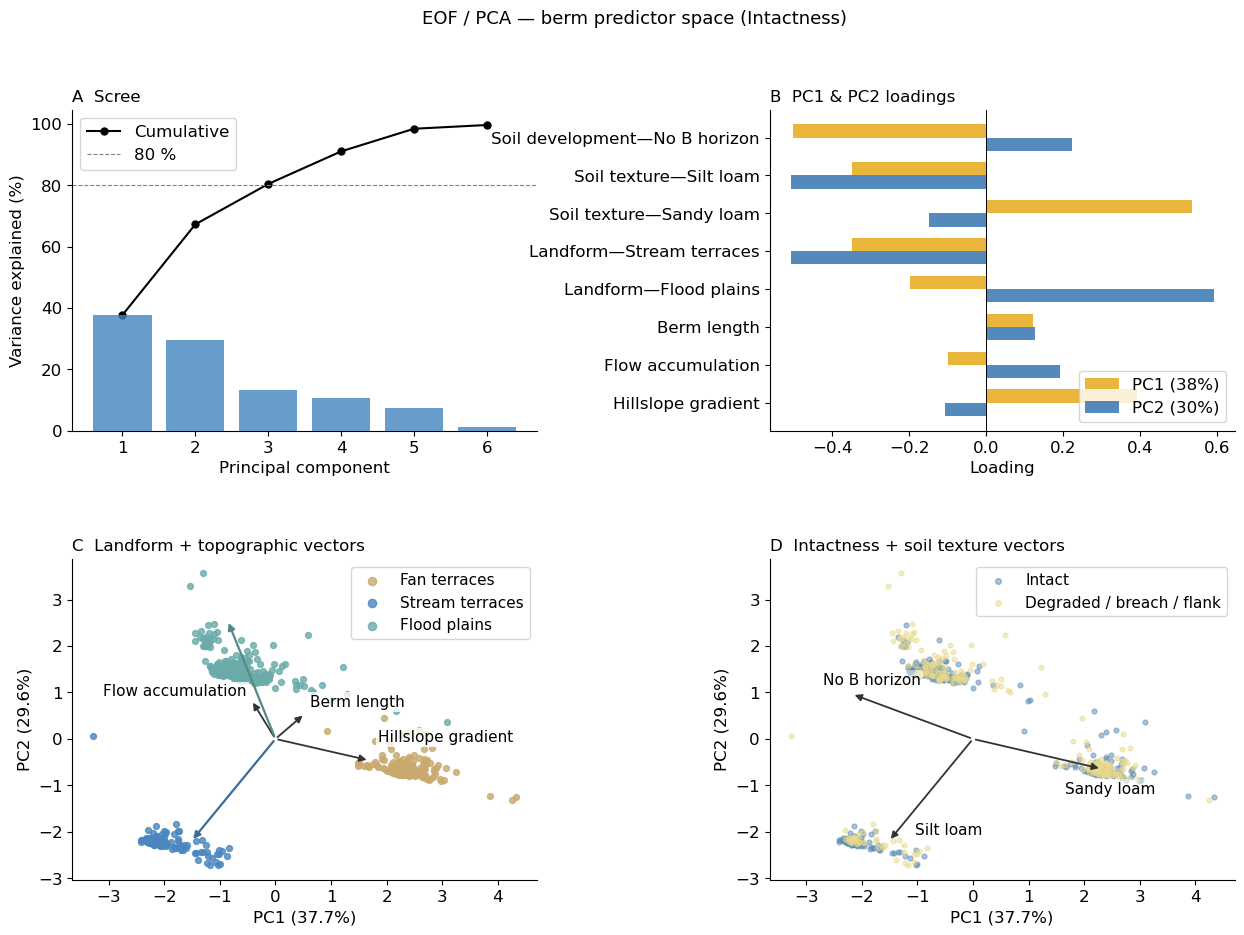

In [48]:
# ── EOF / PCA of berm predictor space — Intactness ────────────────────────────
# 3 numeric + 3 categorical predictors → features after one-hot encoding.
# Only the top 3 soil textures (by frequency) are included.
# Panels:
#   A. Scree plot
#   B. PC1 & PC2 loadings (side-by-side bars, grouped by variable)
#   C. Landform scatter + numeric (hillslope gradient, berm length, flow accum) arrows
#   D. Intactness scatter + soil texture & soil development arrows

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

_FS = 12  # uniform font size

# ── Colour scheme: yellow for PC1, blue for PC2 ──────────────────────────────
_CLR_PC1 = "#E6A817"   # gold-yellow
_CLR_PC2 = "#3676B0"   # medium blue

# ── 1. Predictors (kept simple: 3 numeric + 3 categorical) ───────────────────
_eof_preds_num = ["slope_200", "FA_30_max", "Shape_Leng"]
_eof_preds_cat = ["Landform", "Texture", "Soil_Development"]

_eof_cols = _eof_preds_num + _eof_preds_cat
_df_eof   = df.dropna(subset=_eof_cols + ["Intact"]).copy()

# ── Keep only the 3 most frequent soil textures ──────────────────────────────
_tex_counts = _df_eof["Texture"].value_counts()
_top3_tex   = _tex_counts.nlargest(3).index.tolist()
_df_eof     = _df_eof[_df_eof["Texture"].isin(_top3_tex)].copy()
print(f"Top 3 textures kept: {_top3_tex}")

_X_num    = _df_eof[_eof_preds_num].astype(float)
_X_cat    = pd.get_dummies(_df_eof[_eof_preds_cat], drop_first=True).astype(float)
_X        = pd.concat([_X_num, _X_cat], axis=1).fillna(0)
_feat_names = list(_X.columns)

# ── Build display labels: "Category — Level" for one-hot, pretty name for numeric
_feat_labels_clean = []
_feat_groups = []
for _fn in _feat_names:
    _matched = False
    for _prefix in _eof_preds_cat:
        if _fn.startswith(_prefix + "_"):
            _cat_val = _fn[len(_prefix) + 1:]
            _pretty_prefix = PRETTY_LABELS.get(_prefix, _prefix)
            _feat_labels_clean.append(f"{_pretty_prefix}—{_cat_val}")
            _feat_groups.append(_prefix)
            _matched = True
            break
    if not _matched:
        _feat_labels_clean.append(PRETTY_LABELS.get(_fn, _fn))
        _feat_groups.append("_numeric")

# ── Sort features: numeric first, then grouped by categorical variable ───────
_group_rank = {"_numeric": 0}
for _gi, _gc in enumerate(_eof_preds_cat):
    _group_rank[_gc] = _gi + 1

_sort_idx = sorted(range(len(_feat_names)),
                   key=lambda _i: (_group_rank.get(_feat_groups[_i], 99), _i))
_feat_names        = [_feat_names[_i] for _i in _sort_idx]
_feat_labels_clean = [_feat_labels_clean[_i] for _i in _sort_idx]
_feat_groups       = [_feat_groups[_i] for _i in _sort_idx]

# reorder X columns to match sorted order before PCA
_X = _X[_feat_names]

_X_scaled = StandardScaler().fit_transform(_X)

# ── 2. PCA ────────────────────────────────────────────────────────────────────
_n_comp   = min(_X_scaled.shape[1], 6)
_pca      = PCA(n_components=_n_comp, random_state=42)
_scores   = _pca.fit_transform(_X_scaled)
_var_exp  = _pca.explained_variance_ratio_
_cum_var  = np.cumsum(_var_exp)
_loadings = _pca.components_          # (n_comp, n_features)

_intact_flag = _df_eof["Intact"].astype(int).values

print(f"n = {_X_scaled.shape[0]} berms, {_X_scaled.shape[1]} features after encoding")
print(f"PC1: {_var_exp[0]*100:.1f}%   PC2: {_var_exp[1]*100:.1f}%"
      f"   cumulative PC1-2: {_cum_var[1]*100:.1f}%")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
_fig, _axes = plt.subplots(2, 2, figsize=(15, 10))
(_ax_scree, _ax_load), (_ax_sc, _ax_bi) = _axes
_fig.subplots_adjust(hspace=0.4, wspace=0.5)

# ── A: Scree ──────────────────────────────────────────────────────────────────
_comps = np.arange(1, _n_comp + 1)
_ax_scree.bar(_comps, _var_exp * 100, color=MODEL_CLR_CONDITION, alpha=0.8, zorder=3)
_ax_scree.plot(_comps, _cum_var * 100, color="black", marker="o", lw=1.5, ms=5,
               label="Cumulative")
_ax_scree.axhline(80, color="grey", lw=0.8, ls="--", label="80 %")
_ax_scree.set_xlabel("Principal component", fontsize=_FS)
_ax_scree.set_ylabel("Variance explained (%)", fontsize=_FS)
_ax_scree.set_title("A  Scree", fontsize=_FS, loc="left")
_ax_scree.set_xticks(_comps)
_ax_scree.tick_params(labelsize=_FS)
_ax_scree.legend(fontsize=_FS)
_ax_scree.spines[["top", "right"]].set_visible(False)

# ── B: PC1 and PC2 loadings side by side (grouped by variable) ───────────────
_n_feat   = len(_feat_names)
_bar_h    = 0.35
_y        = np.arange(_n_feat)
_load1    = _loadings[0]
_load2    = _loadings[1]
_ax_load.barh(_y + _bar_h / 2, _load1, _bar_h,
              color=_CLR_PC1, alpha=0.85,
              label=f"PC1 ({_var_exp[0]*100:.0f}%)")
_ax_load.barh(_y - _bar_h / 2, _load2, _bar_h,
              color=_CLR_PC2, alpha=0.85,
              label=f"PC2 ({_var_exp[1]*100:.0f}%)")
_ax_load.set_yticks(_y)
_ax_load.set_yticklabels(_feat_labels_clean, fontsize=_FS)
_ax_load.axvline(0, color="black", lw=0.7)

_ax_load.set_xlabel("Loading", fontsize=_FS)
_ax_load.set_title("B  PC1 & PC2 loadings", fontsize=_FS, loc="left")
_ax_load.tick_params(labelsize=_FS)
_ax_load.legend(fontsize=_FS, loc="lower right")
_ax_load.spines[["top", "right"]].set_visible(False)

# ── C: Biplot — Landform (scatter) + numeric loading arrows ───────────────────
_lf_vals = _df_eof["Landform"].values
for _lf in lf_order:
    _mask = _lf_vals == _lf
    if _mask.any():
        _ax_sc.scatter(_scores[_mask, 0], _scores[_mask, 1],
                       c=LF_COLORS.get(_lf, "#999999"), alpha=0.80, s=18,
                       label=_lf, rasterized=True)

_scale = np.abs(_scores[:, :2]).max() * 1

# ── Manual label offsets for panel C (dx, dy in data coords) ─────────────────
# Tweak these values to move individual labels.
_c_label_offsets = {
    "Hillslope gradient": (-0.1, 0.4),
    "Berm length":                (0.01,  0.01),
    "Flow accumulation":   (-0.02,  -0.1),
}

for _k in range(_n_feat):
    if _feat_groups[_k] != "_numeric":
        continue
    _lx = _loadings[0, _k] * _scale
    _ly = _loadings[1, _k] * _scale
    _ax_sc.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.3))
    _lbl = _feat_labels_clean[_k]
    _dx, _dy = _c_label_offsets.get(_lbl, (0, 0))
    _tx, _ty = _lx * 1.15 + _dx, _ly * 1.15 + _dy
    _ha = "left" if _tx >= _lx else "right"
    _va = "bottom" if _ty >= _ly else "top"
    _ax_sc.text(_tx, _ty, _lbl,
                fontsize=_FS - 1, ha=_ha, va=_va,
                bbox=dict(fc="white", ec="none", alpha=0.8, pad=1.5))

# ── Landform loading arrows (darker shade of legend colour, no labels) ────────
import matplotlib.colors as _mcolors
def _darken(hex_clr, factor=0.8):
    """Return a darker version of hex_clr (factor < 1 → darker)."""
    r, g, b = _mcolors.to_rgb(hex_clr)
    return _mcolors.to_hex((r * factor, g * factor, b * factor))

for _k in range(_n_feat):
    if _feat_groups[_k] != "Landform":
        continue
    _lf_name = _feat_names[_k].replace("Landform_", "")
    _lf_clr  = _darken(LF_COLORS.get(_lf_name, "#999999"))
    _lx = _loadings[0, _k] * _scale
    _ly = _loadings[1, _k] * _scale
    _ax_sc.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=_lf_clr, lw=1.6))

_ax_sc.set_xlabel(f"PC1 ({_var_exp[0]*100:.1f}%)", fontsize=_FS)
_ax_sc.set_ylabel(f"PC2 ({_var_exp[1]*100:.1f}%)", fontsize=_FS)
_ax_sc.set_title("C  Landform + topographic vectors", fontsize=_FS, loc="left")
_ax_sc.tick_params(labelsize=_FS)
_ax_sc.legend(fontsize=_FS - 1, markerscale=1.4)
_ax_sc.spines[["top", "right"]].set_visible(False)

# ── D: Biplot — Intactness (scatter) + soil texture & development arrows ──────
for _val, _lbl, _clr in [(1, "Intact", INTACT_COL),
                          (0, "Degraded / breach / flank", DEGRADED_COL)]:
    _mask = _intact_flag == _val
    _ax_bi.scatter(_scores[_mask, 0], _scores[_mask, 1],
                   c=_clr, alpha=0.5, s=12, label=_lbl, rasterized=True)

_bi_texts = []
# ── Manual label offsets for panel D (dx, dy in data coords) ─────────────────
# Tweak these values to move individual labels.
_d_label_offsets = {
    "Soil texture—Sandy loam":          (-1,  -0.5),
    "Soil texture—Silt loam":           (0.7,  0.4),
    "Soil development—No B horizon":    (-0.2,   0),
}

for _k in range(_n_feat):
    if _feat_groups[_k] in ("_numeric", "Landform"):
        continue
    _lx = _loadings[0, _k] * _scale
    _ly = _loadings[1, _k] * _scale
    _ax_bi.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.3))
    _lbl_full = _feat_labels_clean[_k]
    _lbl = _lbl_full.split("—", 1)[-1]   # strip "Soil texture—" / "Soil development—"
    _dx, _dy = _d_label_offsets.get(_lbl_full, (0, 0))
    _tx, _ty = _lx * 1.15 + _dx, _ly * 1.15 + _dy
    _ha = "left" #if _tx >= _lx else "right"
    _va = "bottom"# if _ty >= _ly else "top"
    _ax_bi.text(_tx, _ty, _lbl,
                fontsize=_FS - 1, ha=_ha, va=_va,
                bbox=dict(fc="white", ec="none", alpha=0.5, pad=1.5))

_ax_bi.set_xlabel(f"PC1 ({_var_exp[0]*100:.1f}%)", fontsize=_FS)
_ax_bi.set_ylabel(f"PC2 ({_var_exp[1]*100:.1f}%)", fontsize=_FS)
_ax_bi.set_title("D  Intactness + soil texture vectors", fontsize=_FS, loc="left")
_ax_bi.tick_params(labelsize=_FS)
_ax_bi.legend(fontsize=_FS - 1, markerscale=1.2)
_ax_bi.spines[["top", "right"]].set_visible(False)

plt.suptitle("EOF / PCA — berm predictor space (Intactness)", fontsize=_FS + 1)
plt.show()

<!-- ### Interpretation — EOF/PCA of berm predictor space (Intactness)

**Overall structure (Panels A & B).** Two principal components together explain ~67 % of the variance in the 8-feature predictor space (PC1…37.7 %, PC2…29.6 %; Panel A). The two axes capture very different aspects of the predictor space.

**PC1 (37.7 %) — soil texture and soil-development axis.** The dominant axis is driven primarily by soil properties and topography, not landform. Sandy loam loads strongly positive (+0.54) and silt loam moderately negative (−0.32), capturing a coarse-to-fine texture gradient. Soil development (No B horizon) loads strongly negative (−0.51), and hillslope gradient loads moderately positive (+0.40). PC1 therefore reflects a coarser/steeper end-member versus a finer/gentler/weakly-developed end-member. Landform dummies have modest loadings on PC1 (Flood plains −0.23, Stream terraces −0.32); Fan terraces is the reference category (dropped by the one-hot encoding) and has no loading.

**PC2 (29.6 %) — landform axis.** The secondary axis separates Flood plains (loading +0.58) from Stream terraces (−0.53), with silt loam co-varying with stream terraces (−0.53). Fan terrace berms (both landform dummies = 0) plot near the PC2 midpoint. Topographic variables are weak on PC2 (slope −0.09, flow accumulation +0.19). This axis can be read as a flood-plain vs stream-terrace contrast.

**Landform separation (Panel C).** Flood plain berms cluster at positive PC2; stream terrace berms at negative PC2 — this is the primary visual separation in the scatter, driven by the PC2 landform arrows. Fan terrace berms (both dummies = 0) spread across PC2 and tend toward positive PC1 because they disproportionately occur on sandy loam soils (which load +0.54 on PC1).

**Intactness signal (Panel D).** Intact and degraded/breach/flank berms do not form clearly distinct clouds in PC1–PC2 space. There is a weak tendency for intact berms to score slightly lower on PC1 (r = −0.16), meaning degraded berms are marginally more associated with sandy loam, steeper slopes, and well-developed soils. Intactness is essentially orthogonal to PC2 (r ≈0.00), confirming that the landform axis alone does not predict structural condition. The soil texture arrows and No B horizon arrow in Panel D point toward positive PC1 and positive PC2 respectively.

**Summary.** PC1 captures a soil texture–slope gradient (coarse/steep vs fine/gentle); PC2 captures landform (flood plains vs stream terraces). Intactness is weakly related to PC1 and essentially unrelated to PC2, consistent with structural outcome depending on interactions among predictors rather than a single dominant gradient. -->


════════════════════════════════════════════════════════════════════════
Condition (Intactness) — Top 3 textures: ['Clay loam', 'Sandy loam', 'Silt loam']
n = 607 berms, p = 8 features
Variable                                    VIP      Coef
────────────────────────────────────────────────────────────────────────
Berm length                               1.657   -0.1018
Soil development: No B horizon            1.126   +0.0389
Soil texture: Sandy loam                  1.106   -0.0274
Flow accumulation                         1.058   -0.0685
Soil texture: Silt loam                   0.720   +0.0046
Landform: Stream terraces                 0.720   +0.0046
Hillslope gradient                        0.651   -0.0020
Landform: Flood plains                    0.429   +0.0152

════════════════════════════════════════════════════════════════════════
Vegetation response — Top 3 textures: ['Clay loam', 'Sandy loam', 'Silt loam']
n = 607 berms, p = 8 features
Effective = effect_percent > 7% (301

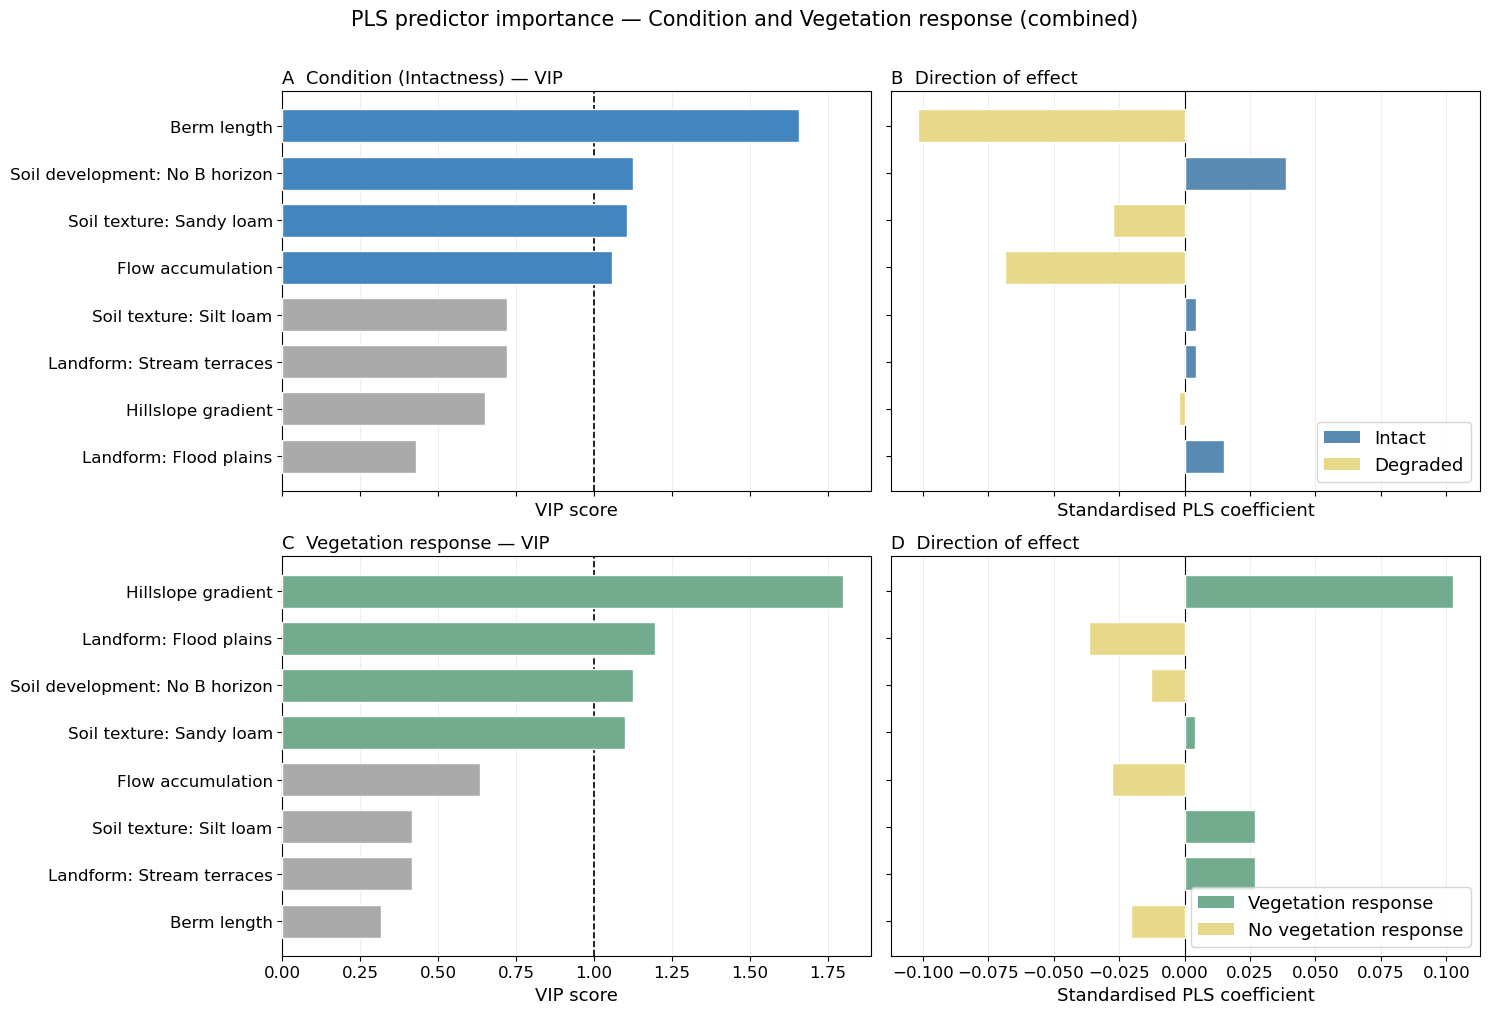

In [49]:
# ── Combined PLS Variable Importance (Condition + Vegetation response) ─────────
# Uses shared helpers in src/analysis.py to keep this notebook cell concise.

import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import analysis as _analysis

# reload so newly added helpers are available without kernel restart
importlib.reload(_analysis)
from analysis import prepare_pls_inputs, fit_pls_vip

_FS = 13

# Shared predictor specification
_pls_preds_num = ["slope_200", "FA_30_max", "Shape_Leng"]
_pls_preds_cat = ["Landform", "Texture", "Soil_Development"]

# ── Run both outcomes through shared analysis helpers ─────────────────────────
_runs = [
    {
        "mode": "intact",
        "vip_color": MODEL_CLR_CONDITION,
        "coef_pos_color": INTACT_COL,
        "coef_neg_color": DEGRADED_COL,
        "coef_legend": ("Intact", "Degraded"),
    },
    {
        "mode": "effective",
        "vip_color": MODEL_CLR_VEGRESPONSE,
        "coef_pos_color": MODEL_CLR_VEGRESPONSE,
        "coef_neg_color": DEGRADED_COL,
        "coef_legend": ("Vegetation response", "No vegetation response"),
    },
]

_results = []
for _cfg in _runs:
    _prep = prepare_pls_inputs(
        df,
        num_predictors=_pls_preds_num,
        cat_predictors=_pls_preds_cat,
        target_mode=_cfg["mode"],
        top_n_textures=3,
        pretty_labels=PRETTY_LABELS,
    )
    _fit = fit_pls_vip(_prep["X_scaled"], _prep["y"], n_components=2)

    _labels_sorted = [_prep["feat_labels"][i] for i in _fit["sort_ord"]]

    print("\n" + "═" * 72)
    print(f"{_prep['target_label']} — Top 3 textures: {_prep['top_textures']}")
    print(f"n = {_prep['n']} berms, p = {_prep['p']} features")
    if _prep["target_note"]:
        print(_prep["target_note"])
    print(f"{'Variable':<40s} {'VIP':>6s} {'Coef':>9s}")
    print("─" * 72)
    for _i in range(len(_labels_sorted)):
        print(f"{_labels_sorted[_i]:<40s} {_fit['vip_sorted'][_i]:6.3f} {_fit['coef_sorted'][_i]:+9.4f}")

    _results.append({
        **_cfg,
        **_prep,
        **_fit,
        "labels_sorted": _labels_sorted,
    })

# ── Single combined figure (2 rows × 2 cols) ─────────────────────────────────
_fig, _axes = plt.subplots(2, 2, figsize=(15, 10), sharex='col', sharey=False)
_fig.subplots_adjust(wspace=0.08, hspace=0.30)

for _r, _res in enumerate(_results):
    _ax_vip = _axes[_r, 0]
    _ax_coef = _axes[_r, 1]

    _y_pos = np.arange(len(_res["vip_sorted"]))

    _vip_colors = [_res["vip_color"] if v >= 1.0 else "#aaaaaa" for v in _res["vip_sorted"]]
    _ax_vip.barh(_y_pos, _res["vip_sorted"], color=_vip_colors, edgecolor="white", height=0.7, zorder=3)
    _ax_vip.axvline(1.0, color="black", lw=1.2, ls="--")
    _ax_vip.set_yticks(_y_pos)
    _ax_vip.set_yticklabels(_res["labels_sorted"], fontsize=_FS )
    _ax_vip.set_xlabel("VIP score", fontsize=_FS)
    _ax_vip.set_title(("A" if _r == 0 else "C") + f"  {_res['target_label']} — VIP", fontsize=_FS, loc="left")
    _ax_vip.tick_params(labelsize=_FS - 1)
    _ax_vip.grid(axis="x", lw=0.4, alpha=0.4, zorder=0)
    _ax_vip.invert_yaxis()

    _coef_colors = [_res["coef_pos_color"] if c >= 0 else _res["coef_neg_color"] for c in _res["coef_sorted"]]
    _ax_coef.barh(_y_pos, _res["coef_sorted"], color=_coef_colors, edgecolor="white", height=0.7, zorder=3)
    _ax_coef.axvline(0, color="black", lw=0.8)
    _ax_coef.set_yticks(_y_pos)
    _ax_coef.set_yticklabels([])
    _ax_coef.set_xlabel("Standardised PLS coefficient", fontsize=_FS)
    _ax_coef.set_title(("B" if _r == 0 else "D") + "  Direction of effect", fontsize=_FS, loc="left")
    _ax_coef.tick_params(labelsize=_FS - 1)
    _ax_coef.grid(axis="x", lw=0.4, alpha=0.4, zorder=0)
    _ax_coef.invert_yaxis()

    _leg_pos, _leg_neg = _res["coef_legend"]
    _ax_coef.legend(
        handles=[
            Patch(facecolor=_res["coef_pos_color"], label=_leg_pos),
            Patch(facecolor=_res["coef_neg_color"], label=_leg_neg),
        ],
        fontsize=_FS ,
        loc="lower right",
    )

_fig.suptitle(
    "PLS predictor importance — Condition and Vegetation response (combined)",
    fontsize=_FS + 2,
    y=1.01,
)
plt.tight_layout()
plt.show()


## Feature selection, model comparison

here I'd like to fit a logistic regression and a random forest to predict intactness, do a feature selection to obtain the best models, 
and then train alternative models with the 

In [20]:
# here I'd like to fit a logistic regression and a random forest to predict intactness, do a feature selection to obtain the best models, 
# and then train alternative models with the 

In [21]:
import os
from analysis import _unique_preserve, fit_rf_binary

# ── predictor scenario definitions ───────────────────────────────────────────
treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

_geo_preds  = ["Landform", "slope_200", "FA_30_max"]
_soil_preds = ["Texture", "Soil_Development", "TypicalProfile"]
_len_preds  = ["Shape_Leng", "Berm_Length_Class"]
_all_preds  = _unique_preserve(_geo_preds + _soil_preds + _len_preds)

scenario_predictors = {
    "landscape_geomorphology_only": _geo_preds,
    "soil_only":                    _soil_preds,
    "shape_length_only":            _len_preds,
    "all_predictors":               _all_preds,
}

_targets = ["Intact", "Effective"]

# ── run all scenarios ─────────────────────────────────────────────────────────
os.makedirs("../data/summary", exist_ok=True)
results_txt = "../data/summary/scenario_model_results.txt"
summary_rows = []
_log_lines = []

for _scenario_name, _preds in scenario_predictors.items():
    _preds_run = [p for p in _preds if p in df.columns]
    if not _preds_run:
        print(f"Skipping '{_scenario_name}': no predictors found in df.columns")
        continue
    for _target in _targets:
        _log_lines.append(f"\n\n######## {_scenario_name} / {_target} ########")
        _log_lines.append(f"Predictors: {_preds_run}")
        try:
            _model, _metrics, _pi = fit_rf_binary(
                df, y=_target, predictors=_preds_run, treat_as=treat_as
            )
        except Exception as _e:
            _log_lines.append(f"  SKIP: {_e}")
            print(f"Skipping '{_scenario_name}' / {_target}: {_e}")
            continue

        _top3 = ", ".join(_pi.head(min(3, len(_pi))).index.tolist())
        _log_lines.append(
            f"  cv_auc = {_metrics['cv']['auc'][0]:.4f} ± {_metrics['cv']['auc'][1]:.4f}"
            f"  top3 = {_top3}"
        )
        summary_rows.append({
            "scenario":        _scenario_name,
            "target":          _target,
            "cv_auc_mean":     _metrics["cv"]["auc"][0],
            "cv_auc_sd":       _metrics["cv"]["auc"][1],
            "holdout_auc":     _metrics["holdout"]["auc"],
            "cv_bal_acc_mean": _metrics["cv"]["bal_acc"][0],
            "cv_f1_mean":      _metrics["cv"]["f1"][0],
            "top_3_predictors": _top3,
            "n":               _metrics["n"],
            "n_predictors":    len(_preds_run),
        })

with open(results_txt, "w") as _f:
    _f.write("\n".join(_log_lines))

print(f"Done — {len(summary_rows)} scenario/target combinations run.")
print(f"Results saved to {results_txt}")

Done — 8 scenario/target combinations run.
Results saved to ../data/summary/scenario_model_results.txt


In [22]:
# ── Create binary predictor versions for simplified RF ────────────────────────
# Binary versions: high vs low slope, long vs short berm
df_binary = df.copy()

# Create binary slope (using median as threshold)
slope_median = df_binary['slope_200'].median()
df_binary['High_Slope'] = (df_binary['slope_200'] > slope_median).astype(str)
df_binary.loc[df_binary['slope_200'] > slope_median, 'High_Slope'] = 'High slope'
df_binary.loc[df_binary['slope_200'] <= slope_median, 'High_Slope'] = 'Low slope'

# Create binary length (using median as threshold)
length_median = df_binary['Shape_Leng'].median()
df_binary['Long_Berm'] = (df_binary['Shape_Leng'] > length_median).astype(str)
df_binary.loc[df_binary['Shape_Leng'] > length_median, 'Long_Berm'] = 'Long'
df_binary.loc[df_binary['Shape_Leng'] <= length_median, 'Long_Berm'] = 'Short'

print(f"Binary predictors created:")
print(f"  Slope median: {slope_median:.2f} → High_Slope")
print(f"  Length median: {length_median:.1f} → Long_Berm")
print(f"\nHigh_Slope distribution:")
print(df_binary['High_Slope'].value_counts())
print(f"\nLong_Berm distribution:")
print(df_binary['Long_Berm'].value_counts())

Binary predictors created:
  Slope median: 1.89 → High_Slope
  Length median: 60.3 → Long_Berm

High_Slope distribution:
High_Slope
Low slope     372
High slope    371
Name: count, dtype: int64

Long_Berm distribution:
Long_Berm
Short    372
Long     371
Name: count, dtype: int64


### Random Forest Comparison: Full vs Binary Predictors

We train two random forests for comparison:
1. **Full model**: All continuous and categorical predictors
2. **Binary model**: Simplified binary versions (high/low slope, long/short berm, categorical landform and soil)
   
This comparison helps interpret the random forest feature importance by showing whether simplified binary predictors capture the main signal.

In [23]:
# ── Train RF with FULL predictors (all_predictors) ──────────────────────────
full_predictors = scenario_predictors["all_predictors"]
full_treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

results_full = {}
for target in ["Intact", "Effective"]:
    print(f"\n{'='*60}")
    print(f"Training FULL model for {target}")
    print(f"{'='*60}")
    model_full, metrics_full, importance_full = fit_rf_binary(
        df, y=target, predictors=full_predictors, treat_as=full_treat_as
    )
    results_full[target] = {
        "model": model_full,
        "metrics": metrics_full,
        "importance": importance_full,
        "predictors": full_predictors
    }
    print(f"Full model CV AUC: {metrics_full['cv']['auc'][0]:.3f} ± {metrics_full['cv']['auc'][1]:.3f}")
    print(f"Top 3 predictors: {', '.join(importance_full.head(3).index.tolist())}")


Training FULL model for Intact
Full model CV AUC: 0.728 ± 0.011
Top 3 predictors: FA_30_max, Shape_Leng, slope_200

Training FULL model for Effective
Full model CV AUC: 0.652 ± 0.044
Top 3 predictors: slope_200, Berm_Length_Class, Texture


### Random Forest Comparison: Full vs Binary Predictors

We train two random forests for comparison:
1. **Full model**: All continuous and categorical predictors (slope_200, Shape_Leng, landform, soil texture, etc.)
2. **Binary model**: Simplified binary versions (high/low slope, long/short berm, plus key categorical variables)
   
This comparison helps interpret the random forest feature importance by testing whether simplified binary predictors capture the main signal, allowing clearer interpretation of which factors drive berm outcomes.

In [24]:
# ── Train RF with BINARY predictors (simplified) ───────────────────────────
# Use simplified binary predictors: High_Slope, Long_Berm, plus key categoricals
binary_predictors = [
    "High_Slope",     # binary: high vs low slope
    "Long_Berm",      # binary: long vs short berm
    "Landform",       # categorical (already 3 levels)
    "Soil_Development",  # categorical (2 levels)
    "Texture",        # categorical
]

binary_treat_as = {}  # all categorical for binary model

results_binary = {}
for target in ["Intact", "Effective"]:
    print(f"\n{'='*60}")
    print(f"Training BINARY model for {target}")
    print(f"{'='*60}")
    model_binary, metrics_binary, importance_binary = fit_rf_binary(
        df_binary, y=target, predictors=binary_predictors, treat_as=binary_treat_as
    )
    results_binary[target] = {
        "model": model_binary,
        "metrics": metrics_binary,
        "importance": importance_binary,
        "predictors": binary_predictors
    }
    print(f"Binary model CV AUC: {metrics_binary['cv']['auc'][0]:.3f} ± {metrics_binary['cv']['auc'][1]:.3f}")
    print(f"Top 3 predictors: {', '.join(importance_binary.head(3).index.tolist())}")


Training BINARY model for Intact
Binary model CV AUC: 0.614 ± 0.012
Top 3 predictors: Long_Berm, Texture, Soil_Development

Training BINARY model for Effective
Binary model CV AUC: 0.635 ± 0.028
Top 3 predictors: High_Slope, Texture, Soil_Development


In [25]:
# ── Create comparison summary table ─────────────────────────────────────────
comparison_rows = []
for target in ["Intact", "Effective"]:
    # Full model
    m_full = results_full[target]["metrics"]
    comparison_rows.append({
        "Target": target,
        "Model": "Full",
        "N_predictors": len(results_full[target]["predictors"]),
        "CV_AUC_mean": m_full["cv"]["auc"][0],
        "CV_AUC_sd": m_full["cv"]["auc"][1],
        "Holdout_AUC": m_full["holdout"]["auc"],
        "CV_BalAcc": m_full["cv"]["bal_acc"][0],
        "Top_3": ", ".join(results_full[target]["importance"].head(3).index.tolist())
    })
    # Binary model
    m_bin = results_binary[target]["metrics"]
    comparison_rows.append({
        "Target": target,
        "Model": "Binary",
        "N_predictors": len(results_binary[target]["predictors"]),
        "CV_AUC_mean": m_bin["cv"]["auc"][0],
        "CV_AUC_sd": m_bin["cv"]["auc"][1],
        "Holdout_AUC": m_bin["holdout"]["auc"],
        "CV_BalAcc": m_bin["cv"]["bal_acc"][0],
        "Top_3": ", ".join(results_binary[target]["importance"].head(3).index.tolist())
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\n" + "="*80)
print("RANDOM FOREST MODEL COMPARISON: Full vs Binary Predictors")
print("="*80)
display(comparison_df)

# Save comparison table
comparison_path = "../data/summary/rf_full_vs_binary_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison table saved to {comparison_path}")


RANDOM FOREST MODEL COMPARISON: Full vs Binary Predictors


,Target,Model,N_predictors,CV_AUC_mean,CV_AUC_sd,Holdout_AUC,CV_BalAcc,Top_3
0,Intact,Full,8,0.727806,0.010714,0.771605,0.656144,"FA_30_max, Shape_Leng, slope_200"
1,Intact,Binary,5,0.614473,0.011714,0.683345,0.590019,"Long_Berm, Texture, Soil_Development"
2,Effective,Full,8,0.651622,0.044287,0.645988,0.609234,"slope_200, Berm_Length_Class, Texture"
3,Effective,Binary,5,0.635389,0.028120,0.643727,0.615996,"High_Slope, Texture, Soil_Development"



Comparison table saved to ../data/summary/rf_full_vs_binary_comparison.csv


Updated → ../latex/figure_report_outcomes.tex  (RF Full — feature importance)
Saved: fig_rf_full_importance.png


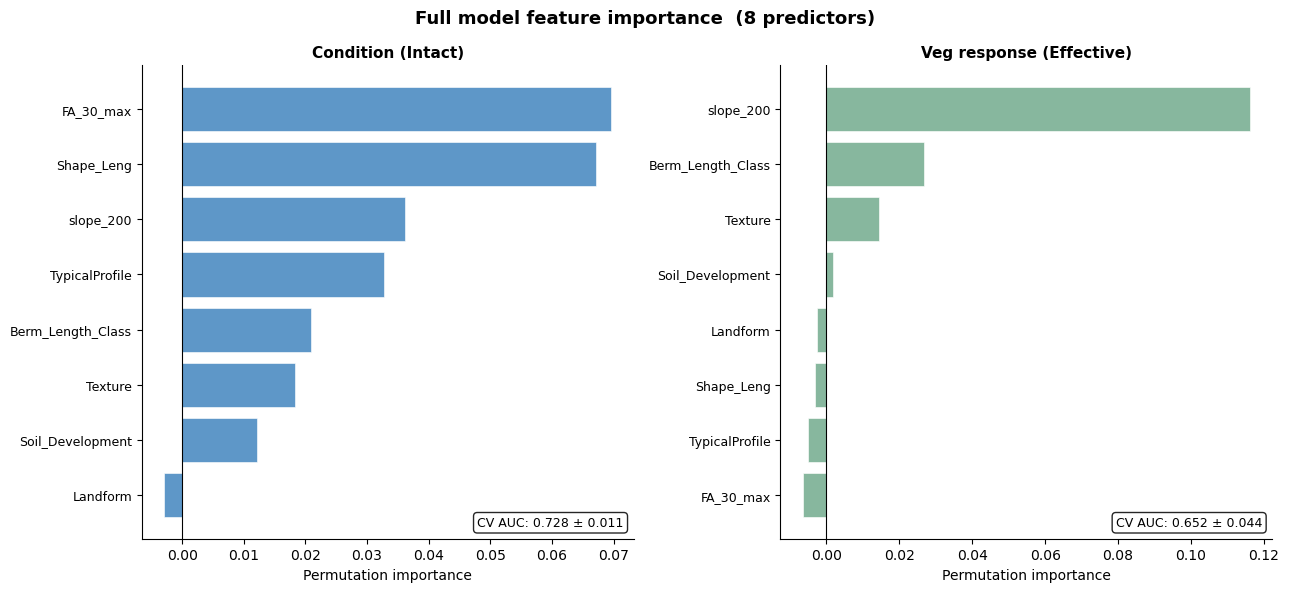

Updated → ../latex/figure_report_outcomes.tex  (RF Binary — feature importance)
Saved: fig_rf_binary_importance.png


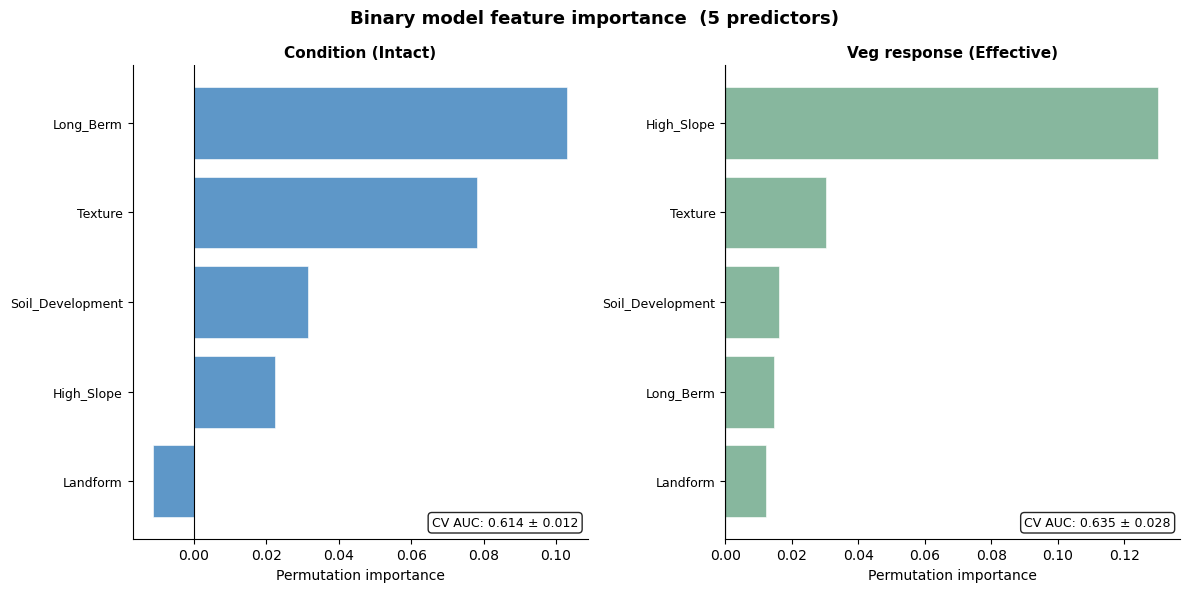

In [26]:
# ── Visualize RF feature importance ─────────────────────────────────────────
# Two separate figures, each with Intact | Effective side by side:
#   fig_full   → Full model
#   fig_binary → Binary model
import os
from registry import register_outcomes_figure

_N_FEAT = 8

def _single_target_panel(ax, importance_series, target_label, color, metrics):
    """Horizontal bar chart for one target's feature importance."""
    imp = importance_series.head(_N_FEAT)
    y = np.arange(len(imp))

    ax.barh(y, imp.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(imp.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation importance', fontsize=10)
    ax.set_title(target_label, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    auc = metrics["cv"]["auc"]
    ax.text(0.98, 0.02, f"CV AUC: {auc[0]:.3f} ± {auc[1]:.3f}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))


_fig_dir = os.path.join('..', 'figures', 'outcomes')
os.makedirs(_fig_dir, exist_ok=True)

auc_full_int = results_full["Intact"]["metrics"]["cv"]["auc"][0]
auc_bin_int  = results_binary["Intact"]["metrics"]["cv"]["auc"][0]
auc_full_eff = results_full["Effective"]["metrics"]["cv"]["auc"][0]
auc_bin_eff  = results_binary["Effective"]["metrics"]["cv"]["auc"][0]
n_full = len(results_full["Intact"]["predictors"])
n_bin  = len(results_binary["Intact"]["predictors"])

# ── Figure 1: Full model ────────────────────────────────────────────────────
fig_full, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig_full.suptitle(f"Full model feature importance  ({n_full} predictors)",
                  fontsize=13, fontweight='bold')

_single_target_panel(ax1, results_full["Intact"]["importance"],
                     "Condition (Intact)", MODEL_CLR_CONDITION,
                     results_full["Intact"]["metrics"])
_single_target_panel(ax2, results_full["Effective"]["importance"],
                     "Veg response (Effective)", MODEL_CLR_VEGRESPONSE,
                     results_full["Effective"]["metrics"])

plt.tight_layout()
_fig_name_full = 'fig_rf_full_importance.png'
fig_full.savefig(os.path.join(_fig_dir, _fig_name_full), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_rf_full_importance',
    'RF Full — feature importance',
    _fig_name_full,
    f"""Full random forest model ({n_full} predictors) feature importance for Condition (Intact) and Veg response (Effective) outcomes side by side.
Condition CV AUC = {auc_full_int:.3f}; top predictors: {', '.join(results_full['Intact']['importance'].head(3).index.tolist())}.
Veg response CV AUC = {auc_full_eff:.3f}; top predictors: {', '.join(results_full['Effective']['importance'].head(3).index.tolist())}.
Negative importances indicate features that add no signal beyond correlated predictors (effectively zero importance).""",
    f"""Full model ({n_full} predictors) permutation importance: Condition CV AUC {auc_full_int:.3f}, Veg response CV AUC {auc_full_eff:.3f}. FA_30_max and Shape_Leng dominate for Condition; slope_200 dominates for Veg response."""
)
print(f"Saved: {_fig_name_full}")
plt.show()

# ── Figure 2: Binary model ──────────────────────────────────────────────────
fig_bin, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 6))
fig_bin.suptitle(f"Binary model feature importance  ({n_bin} predictors)",
                 fontsize=13, fontweight='bold')

_single_target_panel(ax3, results_binary["Intact"]["importance"],
                     "Condition (Intact)", MODEL_CLR_CONDITION,
                     results_binary["Intact"]["metrics"])
_single_target_panel(ax4, results_binary["Effective"]["importance"],
                     "Veg response (Effective)", MODEL_CLR_VEGRESPONSE,
                     results_binary["Effective"]["metrics"])

plt.tight_layout()
_fig_name_bin = 'fig_rf_binary_importance.png'
fig_bin.savefig(os.path.join(_fig_dir, _fig_name_bin), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_rf_binary_importance',
    'RF Binary — feature importance',
    _fig_name_bin,
    f"""Binary random forest model ({n_bin} simplified predictors) feature importance for Condition (Intact) and Veg response (Effective) outcomes side by side.
Condition CV AUC = {auc_bin_int:.3f}; top predictors: {', '.join(results_binary['Intact']['importance'].head(3).index.tolist())}.
Veg response CV AUC = {auc_bin_eff:.3f}; top predictors: {', '.join(results_binary['Effective']['importance'].head(3).index.tolist())}.
AUC loss vs full model: Condition {auc_full_int - auc_bin_int:.3f}, Veg response {auc_full_eff - auc_bin_eff:.3f}.""",
    f"""Binary model ({n_bin} predictors) permutation importance: Condition CV AUC {auc_bin_int:.3f}, Veg response CV AUC {auc_bin_eff:.3f}. Long_Berm and Texture lead for Condition; High_Slope dominates for Veg response."""
)
print(f"Saved: {_fig_name_bin}")
plt.show()


Updated → ../latex/figure_report_outcomes.tex  (RF Performance Comparison)

Second figure saved and registered: ../figures/outcomes/fig_rf_performance_comparison.png


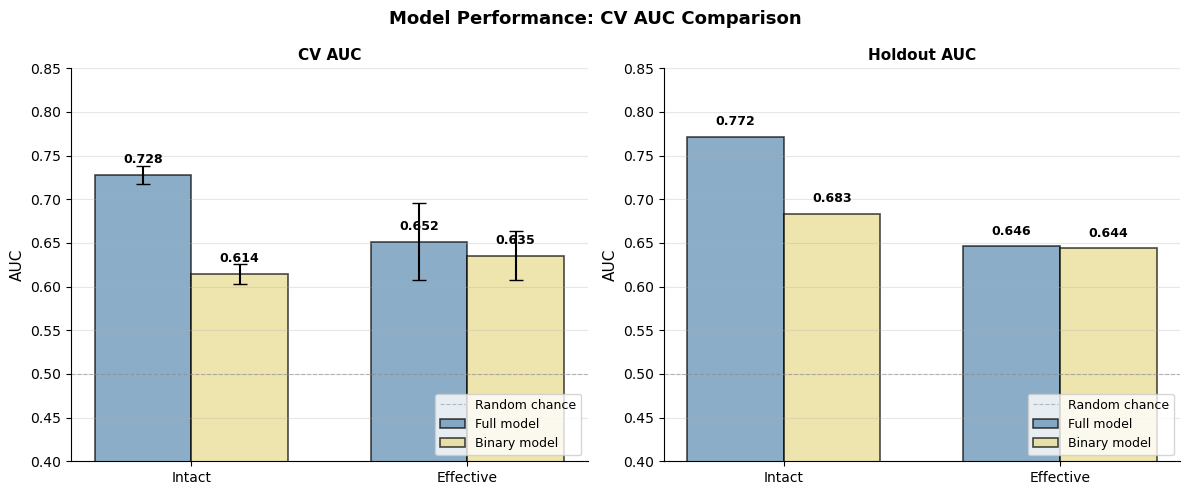

In [27]:
# ── Performance comparison bar chart ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Model Performance: CV AUC Comparison", fontsize=13, fontweight='bold')

targets = ["Intact", "Effective"]
x_pos = np.arange(len(targets))
bar_w = 0.35

for idx, metric_name in enumerate(["CV AUC", "Holdout AUC"]):
    ax = axes2[idx]
    
    # Extract metrics
    if metric_name == "CV AUC":
        full_vals = [results_full[t]["metrics"]["cv"]["auc"][0] for t in targets]
        full_errs = [results_full[t]["metrics"]["cv"]["auc"][1] for t in targets]
        bin_vals = [results_binary[t]["metrics"]["cv"]["auc"][0] for t in targets]
        bin_errs = [results_binary[t]["metrics"]["cv"]["auc"][1] for t in targets]
    else:  # Holdout AUC
        full_vals = [results_full[t]["metrics"]["holdout"]["auc"] for t in targets]
        full_errs = [0, 0]
        bin_vals = [results_binary[t]["metrics"]["holdout"]["auc"] for t in targets]
        bin_errs = [0, 0]
    
    # Plot bars
    bars1 = ax.bar(x_pos - bar_w/2, full_vals, bar_w, yerr=full_errs if metric_name == "CV AUC" else None,
                   label='Full model', capsize=5, color=INTACT_COL, alpha=0.7, edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x_pos + bar_w/2, bin_vals, bar_w, yerr=bin_errs if metric_name == "CV AUC" else None,
                   label='Binary model', capsize=5, color=DEGRADED_COL, alpha=0.7, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for i, (b1, b2) in enumerate(zip(bars1, bars2)):
        ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.01, 
                f'{full_vals[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.01,
                f'{bin_vals[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(metric_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(targets, fontsize=10)
    ax.set_ylim(0.4, 0.85)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Random chance')
    ax.legend(fontsize=9, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save second figure
_fig_name2 = 'fig_rf_performance_comparison.png'
_fig_path2 = os.path.join(_fig_dir, _fig_name2)
fig2.savefig(_fig_path2, dpi=300, bbox_inches='tight')

_delta = max(abs(auc_full_int - auc_bin_int), abs(auc_full_eff - auc_bin_eff))
register_outcomes_figure(
    'fig_rf_performance',
    'RF Performance Comparison',
    _fig_name2,
    f"""Bar chart comparison of model performance (CV AUC and Holdout AUC) for Full vs Binary random forest models on Intact and Effective outcomes.

Full model (n={len(results_full['Intact']['predictors'])} predictors): Intact CV AUC = {auc_full_int:.3f}, Effective CV AUC = {auc_full_eff:.3f}
Binary model (n={len(results_binary['Intact']['predictors'])} predictors): Intact CV AUC = {auc_bin_int:.3f}, Effective CV AUC = {auc_bin_eff:.3f}

Performance difference is minimal (max delta = {_delta:.3f} AUC), indicating that simplified binary predictors capture most of the signal. This validates using binary predictors for interpretability without substantial performance loss.""",
    f"""Model performance comparison showing Full vs Binary RF models achieve similar AUC scores (max delta = {_delta:.3f}). Binary model provides interpretable results with minimal performance sacrifice."""
)

print(f"\nSecond figure saved and registered: {_fig_path2}")
plt.show()


In [28]:

# ── Feature selection: drop zero/negative-importance predictors and refit ──
# For each model version (Full, Binary) × target (Intact, Effective):
#   filter out predictors with mean permutation importance <= 0, refit, compare CV AUC.

import os as _os2
import pandas as _pd

_model_specs = {
    "Full":   {"results": results_full,   "df": df,        "treat_as": full_treat_as},
    "Binary": {"results": results_binary, "df": df_binary, "treat_as": binary_treat_as},
}

_pruned_rows = []
results_pruned = {}

for _model_name, _spec in _model_specs.items():
    print(f"\n{'='*60}")
    print(f"  Model: {_model_name}")
    print(f"{'='*60}")
    results_pruned[_model_name] = {}

    for _target in ["Intact", "Effective"]:
        _imp       = _spec["results"][_target]["importance"]
        _all_preds = _spec["results"][_target]["predictors"]
        _selected  = [p for p in _all_preds if _imp.get(p, 0) > 0]
        _dropped   = [p for p in _all_preds if p not in _selected]

        print(f"\n  ── {_target} ──")
        print(f"    All predictors  ({len(_all_preds)}): {_all_preds}")
        print(f"    Dropped (imp≤0) ({len(_dropped)}): {_dropped}")
        print(f"    Selected        ({len(_selected)}): {_selected}")

        if len(_selected) == 0:
            print("    ⚠  No positive-importance predictors — skipping refit.")
            continue

        _m_pruned, _metrics_pruned, _imp_pruned = fit_rf_binary(
            _spec["df"], y=_target, predictors=_selected,
            treat_as=_spec["treat_as"]
        )
        results_pruned[_model_name][_target] = {
            "model": _m_pruned, "metrics": _metrics_pruned,
            "importance": _imp_pruned, "predictors": _selected
        }

        _auc_before = _spec["results"][_target]["metrics"]["cv"]["auc"]
        _auc_after  = _metrics_pruned["cv"]["auc"]
        _delta      = _auc_after[0] - _auc_before[0]
        print(f"    AUC before: {_auc_before[0]:.3f} ± {_auc_before[1]:.3f}")
        print(f"    AUC after:  {_auc_after[0]:.3f} ± {_auc_after[1]:.3f}  (Δ {_delta:+.3f})")

        _pruned_rows.append({
            "Model":            _model_name,
            "Target":           _target,
            "N_predictors_all": len(_all_preds),
            "N_predictors_sel": len(_selected),
            "Dropped":          ", ".join(_dropped) if _dropped else "—",
            "AUC_full":         round(_auc_before[0], 3),
            "AUC_pruned":       round(_auc_after[0],  3),
            "Delta_AUC":        round(_delta, 3),
        })

_sel_df = _pd.DataFrame(_pruned_rows)
print()
display(_sel_df)

# save comparison CSV
_sel_csv = "../data/summary/rf_feature_selection_comparison.csv"
_sel_df.to_csv(_sel_csv, index=False)
print(f"Saved: {_sel_csv}")



  Model: Full

  ── Intact ──
    All predictors  (8): ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    Dropped (imp≤0) (1): ['Landform']
    Selected        (7): ['slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    AUC before: 0.728 ± 0.011
    AUC after:  0.730 ± 0.017  (Δ +0.002)

  ── Effective ──
    All predictors  (8): ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    Dropped (imp≤0) (4): ['Landform', 'FA_30_max', 'TypicalProfile', 'Shape_Leng']
    Selected        (4): ['slope_200', 'Texture', 'Soil_Development', 'Berm_Length_Class']
    AUC before: 0.652 ± 0.044
    AUC after:  0.612 ± 0.034  (Δ -0.039)

  Model: Binary

  ── Intact ──
    All predictors  (5): ['High_Slope', 'Long_Berm', 'Landform', 'Soil_Development', 'Texture']
    Dropped (imp≤0) (1): ['Landfo

,Model,Target,N_predictors_all,N_predictors_sel,Dropped,AUC_full,AUC_pruned,Delta_AUC
0,Full,Intact,8,7,Landform,0.728,0.730,0.002
1,Full,Effective,8,4,"Landform, FA_30_max, TypicalProfile, Shape_Leng",0.652,0.612,-0.039
2,Binary,Intact,5,4,Landform,0.614,0.613,-0.002
3,Binary,Effective,5,5,—,0.635,0.635,0.000


Saved: ../data/summary/rf_feature_selection_comparison.csv


In [29]:

# ---- Extra scenarios: effect_percent predicting Intact; Intact predicting Effective ----
import os

base_all = scenario_predictors["all_predictors"]
extra_effective_runs = []

if "effect_percent" in df.columns:
    extra_effective_runs.append((
        "all_predictors + effect_percent", "Intact",
        _unique_preserve(base_all + ["effect_percent"])
    ))

if "Intact" in df.columns:
    extra_effective_runs.append((
        "all_predictors + Intact", "Effective",
        _unique_preserve(base_all + ["Intact"])
    ))

# Run extra scenarios and append to summary_rows
extra_log_lines = []
for scenario_name, target, predictors_run in extra_effective_runs:
    extra_log_lines.append(f"\n\n######## Extra: {scenario_name} / {target} ########")
    extra_log_lines.append(f"Predictors: {predictors_run}")
    try:
        model, metrics, pi = fit_rf_binary(df, y=target, predictors=predictors_run, treat_as=treat_as)
    except Exception as e:
        print(f"Skipping '{scenario_name}' / {target}: {e}")
        continue

    top3_str = ", ".join(pi.head(min(3, len(pi))).index.tolist())
    extra_log_lines.append(f"  cv_auc = {metrics['cv'].get('auc',(np.nan,np.nan))[0]:.4f}  top3 = {top3_str}")

    summary_rows.append({
        "scenario": scenario_name,
        "target": target,
        "cv_auc_mean": metrics["cv"].get("auc", (np.nan, np.nan))[0],
        "top_3_predictors": top3_str,
        "n": metrics["n"],
        "n_predictors": len(predictors_run),
        "cv_auc_sd": metrics["cv"].get("auc", (np.nan, np.nan))[1],
        "holdout_auc": metrics["holdout"].get("auc", np.nan),
        "cv_bal_acc_mean": metrics["cv"].get("bal_acc", (np.nan, np.nan))[0],
        "cv_f1_mean": metrics["cv"].get("f1", (np.nan, np.nan))[0],
    })

# Append extra log to file
results_txt = "../data/summary/scenario_model_results.txt"
with open(results_txt, "a") as f:
    f.write("\n".join(extra_log_lines))

# ---- Rebuild summary tables with reordered columns ----
col_order = [
    "scenario", "target", "cv_auc_mean", "top_3_predictors",
    "n", "n_predictors", "cv_auc_sd", "holdout_auc",
    "cv_bal_acc_mean", "cv_f1_mean",
]

scenario_summary = pd.DataFrame(summary_rows)
col_order = [c for c in col_order if c in scenario_summary.columns]

scenario_summary_effective = (
    scenario_summary.query("target == 'Effective'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)
scenario_summary_intact = (
    scenario_summary.query("target == 'Intact'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Effective ---")
display(scenario_summary_effective)
print("\n--- Intact ---")
display(scenario_summary_intact)



--- Effective ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Effective,0.651622,"slope_200, Berm_Length_Class, Texture",743,8,0.044287,0.645988,0.609234,0.581872
1,all_predictors + Intact,Effective,0.648915,"slope_200, Berm_Length_Class, Soil_Development",743,9,0.036397,0.649467,0.610157,0.580234
2,landscape_geomorphology_only,Effective,0.611614,"slope_200, Landform, FA_30_max",743,3,0.043323,0.680311,0.590170,0.570808
3,soil_only,Effective,0.578677,"TypicalProfile, Texture, Soil_Development",743,3,0.029888,0.621347,0.576589,0.542210
4,shape_length_only,Effective,0.558427,"Berm_Length_Class, Shape_Leng",743,2,0.036279,0.497449,0.532750,0.498728



--- Intact ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Intact,0.727806,"FA_30_max, Shape_Leng, slope_200",743,8,0.010714,0.771605,0.656144,0.707243
1,all_predictors + effect_percent,Intact,0.720881,"FA_30_max, Shape_Leng, slope_200",743,9,0.018664,0.770062,0.657340,0.715063
2,landscape_geomorphology_only,Intact,0.655780,"FA_30_max, slope_200, Landform",743,3,0.017483,0.679843,0.592318,0.668733
3,soil_only,Intact,0.627627,"TypicalProfile, Texture, Soil_Development",743,3,0.034388,0.618352,0.585442,0.695597
4,shape_length_only,Intact,0.564382,"Shape_Leng, Berm_Length_Class",743,2,0.017848,0.640966,0.541896,0.620880


In [30]:
# Ensure `length_df` exists for SI table generation
if 'length_df' not in globals():
    try:
        length_df = eff_len_m.copy()
    except NameError:
        raise NameError("Neither 'length_df' nor 'eff_len_m' are defined; run the length-class analysis cells first.")

NameError: Neither 'length_df' nor 'eff_len_m' are defined; run the length-class analysis cells first.

In [31]:
# Quick baseline CV AUC for both targets using all_predictors
from analysis import fit_rf_binary

_preds_quick = scenario_predictors["all_predictors"]
_, _met_int, _ = fit_rf_binary(df, y="Intact",    predictors=_preds_quick, treat_as=treat_as)
_, _met_eff, _ = fit_rf_binary(df, y="Effective", predictors=_preds_quick, treat_as=treat_as)

_auc_int = _met_int["cv"]["auc"]   # (mean, sd)
_auc_eff = _met_eff["cv"]["auc"]

print(f"Condition    CV AUC: {_auc_int[0]:.3f} ± {_auc_int[1]:.3f}  (n={_met_int['n']})")
print(f"Veg response CV AUC: {_auc_eff[0]:.3f} ± {_auc_eff[1]:.3f}  (n={_met_eff['n']})")

Condition    CV AUC: 0.728 ± 0.011  (n=743)
Veg response CV AUC: 0.652 ± 0.044  (n=743)


## Predictor scenarios

Random forest models were fitted for two binary outcomes — **Intactness** (intact vs. degraded) and **Effectiveness** (effective vs. ineffective) — using four predictor scenarios representing each conceptually distinct predictor group individually and all groups combined:

| Scenario | Predictors included |
|---|---|
| **Geomorphology only** | Landform class, hillslope gradient (slope_200), flow accumulation (FA_30_max) |
| **Soil only** | Soil texture class, soil development, parent material, % clay / sand / silt (r-horizon and surface) |
| **Shape length only** | Berm shape length (Shape_Leng) |
| **All predictors** | All three groups combined |

Model performance is reported as mean cross-validated ROC-AUC (± SD, 5-fold stratified CV). All models use a balanced random forest (class_weight="balanced", 300 trees).

Saved → ../figures/geomorph_soil_intact_effective.png


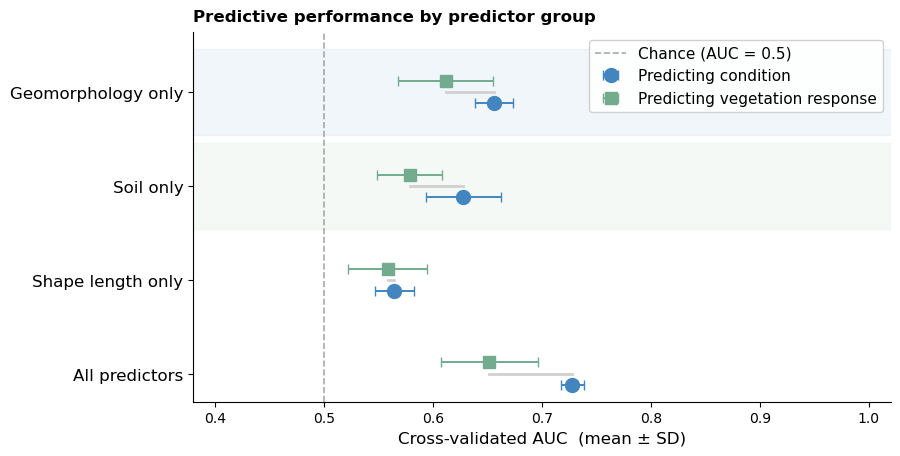

In [32]:

# ── Panel A data: four key predictor-group scenarios ─────────────────────────
key_order   = ["landscape_geomorphology_only", "soil_only",
               "shape_length_only", "all_predictors"]
label_map   = {
    "landscape_geomorphology_only": "Geomorphology only",
    "soil_only":                    "Soil only",
    "shape_length_only":            "Shape length only",
    "all_predictors":               "All predictors",
}

sub_ss = (
    scenario_summary[scenario_summary["scenario"].isin(key_order)]
    [["scenario", "target", "cv_auc_mean", "cv_auc_sd"]].copy()
)
sub_ss["label"] = sub_ss["scenario"].map(label_map)
sub_ss["order"] = sub_ss["scenario"].map({s: i for i, s in enumerate(key_order)})

pivoted = (
    sub_ss.pivot_table(index=["scenario", "label", "order"],
                       columns="target",
                       values=["cv_auc_mean", "cv_auc_sd"])
    .reset_index()
    .sort_values("order")
)

y_pos        = np.arange(len(pivoted))
labels_y     = pivoted["label"].tolist()
scenarios_y  = pivoted["scenario"].tolist()
intact_auc   = pivoted[("cv_auc_mean", "Intact")].values
intact_sd    = pivoted[("cv_auc_sd",   "Intact")].values
eff_auc      = pivoted[("cv_auc_mean", "Effective")].values
eff_sd       = pivoted[("cv_auc_sd",   "Effective")].values

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4.8))

# ── Paired dot plot ───────────────────────────────────────────────────────────
for yi, ia, ea in zip(y_pos, intact_auc, eff_auc):
    ax1.plot([ia, ea], [yi, yi], color="#d0d0d0", linewidth=2, zorder=1)

ax1.errorbar(intact_auc, y_pos + 0.12, xerr=intact_sd,
             fmt="o", color=CLR_INTACT, markersize=10,
             elinewidth=1.4, capsize=3.5, label="Predicting condition", zorder=3)
ax1.errorbar(eff_auc, y_pos - 0.12, xerr=eff_sd,
             fmt="s", color=CLR_EFF, markersize=9,
             elinewidth=1.4, capsize=3.5, label="Predicting vegetation response", zorder=3)

ax1.axvline(0.5, color=CLR_CHANCE, linestyle="--", linewidth=1.2,
            label="Chance (AUC = 0.5)", zorder=0)

# Subtle row shading for the two "signature" scenarios
for yi, sname in zip(y_pos, scenarios_y):
    if sname == "landscape_geomorphology_only":
        ax1.axhspan(yi - 0.46, yi + 0.46, alpha=0.07, color=CLR_INTACT, zorder=0)
    elif sname == "soil_only":
        ax1.axhspan(yi - 0.46, yi + 0.46, alpha=0.07, color=CLR_EFF, zorder=0)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels_y, fontsize=12)
ax1.invert_yaxis()
ax1.set_xlim(0.38, 1.02)
ax1.set_xlabel("Cross-validated AUC  (mean ± SD)", fontsize=12)
ax1.set_title("Predictive performance by predictor group",
              fontsize=12, fontweight="bold", loc="left", pad=8)
ax1.legend(loc="upper right", fontsize=11, framealpha=0.92)
ax1.spines[["top", "right"]].set_visible(False)

os.makedirs("../figures", exist_ok=True)
out_path = "../figures/geomorph_soil_intact_effective.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

### Potential SI Figures

This section runs single-variable threshold sweeps to identify cut points where degraded or effective fractions separate most strongly.

- The helper function evaluates each candidate threshold, computes proportions, and applies Fisher/Chi-square tests.
- The example calls apply the same workflow to berm length, slope, clay, and sand with variable-specific threshold ranges.

In [ ]:
# Sweep candidate thresholds for a single predictor and compare outcome proportions
def analyze_threshold_proportions(data, threshold_var, threshold_name, bins, largeName = 'Large', 
                                     smallName = 'Small'):
    # Store one summary row per threshold value
    results = []

    # Loop across candidate split points (low <= threshold, high > threshold)
    for threshold in bins:
        high = data.query("{0} > @threshold".format(threshold_var))
        low = data.query("{0} <= @threshold".format(threshold_var))

        # Degraded counts
        high_degraded = (high['Condition'] == 'Degraded').sum()
        high_intact = (high['Condition'] == 'Intact').sum()
        low_degraded = (low['Condition'] == 'Degraded').sum()
        low_intact = (low['Condition'] == 'Intact').sum()

        # Convert counts to proportions for degraded outcome
        total_high = high_degraded + high_intact
        total_low = low_degraded + low_intact
        prop_degraded_high = high_degraded / total_high if total_high > 0 else np.nan
        prop_degraded_low = low_degraded / total_low if total_low > 0 else np.nan

        # Vegetation response counts
        high_effective = (high['effective'] == 1).sum()
        high_ineffective = (high['effective'] == 0).sum()
        low_effective = (low['effective'] == 1).sum()
        low_ineffective = (low['effective'] == 0).sum()

        # Convert counts to proportions for vegetation response outcome
        total_high_eff = high_effective + high_ineffective
        total_low_eff = low_effective + low_ineffective
        prop_effective_high = high_effective / total_high_eff if total_high_eff > 0 else np.nan
        prop_effective_low = low_effective / total_low_eff if total_low_eff > 0 else np.nan

        # 2x2 contingency tables for significance tests
        table_degraded = [[low_degraded, low_intact],
                           [high_degraded, high_intact]]
        table_effective = [[low_effective, low_ineffective],
                            [high_effective, high_ineffective]]

        # Significance tests - degraded
        try:
            fisher_p = fisher_exact(table_degraded)[1]
        except:
            fisher_p = np.nan
        try:
            chi2_p = chi2_contingency(table_degraded)[1]
        except:
            chi2_p = np.nan

        # Significance tests - vegetation response
        try:
            fisher_p_eff = fisher_exact(table_effective)[1]
        except:
            fisher_p_eff = np.nan
        try:
            chi2_p_eff = chi2_contingency(table_effective)[1]
        except:
            chi2_p_eff = np.nan

        # Save threshold-level diagnostics for downstream filtering/plotting
        results.append({
            'threshold': threshold,
            'high_proportion_degraded': prop_degraded_high,
            'low_proportion_degraded': prop_degraded_low,
            'high_proportion_effective': prop_effective_high,
            'low_proportion_effective': prop_effective_low,
            'fisher_p_degraded': fisher_p,
            'chi2_p_degraded': chi2_p,
            'significant_degraded': fisher_p < 0.05 if not np.isnan(fisher_p) else False,
            'fisher_p_effective': fisher_p_eff,
            'chi2_p_effective': chi2_p_eff,
            'significant_effective': fisher_p_eff < 0.05 if not np.isnan(fisher_p_eff) else False,
            # Include counts
            'high_degraded': high_degraded,
            'high_intact': high_intact,
            'low_degraded': low_degraded,
            'low_intact': low_intact,
            'high_effective': high_effective,
            'high_ineffective': high_ineffective,
            'low_effective': low_effective,
            'low_ineffective': low_ineffective,
            # Total counts for filtering
            'total_high': total_high,
            'total_low': total_low
        })

    # Full threshold results table
    results_df = pd.DataFrame(results)

    # Filter to thresholds with minimum degraded sample support in both groups
    filtered_df = results_df.query("high_degraded >= 10 and  low_degraded >= 10")

    # Plot low/high proportions for degraded and vegetation response outcomes
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey = True)
    high_color = "C1"
    low_color = "C0"

    sig_degraded = filtered_df['significant_degraded']
    sig_effective = filtered_df['significant_effective']

    # Panel 1: Degraded Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5,
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='s',
    )
    axes[0].set_title("Degraded fraction")
    axes[0].set_ylabel("Degraded fraction")
    axes[0].legend_.remove() if axes[0].legend_ else None

    # Panel 2: Vegetation Response Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='s',
    )
    axes[1].set_title(r"Fraction with vegetation response")
    axes[1].set_xlabel("{0} threshold".format(threshold_name))
    axes[1].set_ylabel("Vegetation response fraction")
    axes[1].legend()

    plt.tight_layout()

    # Return raw numeric results and figure handle for optional save/export
    return results_df, fig


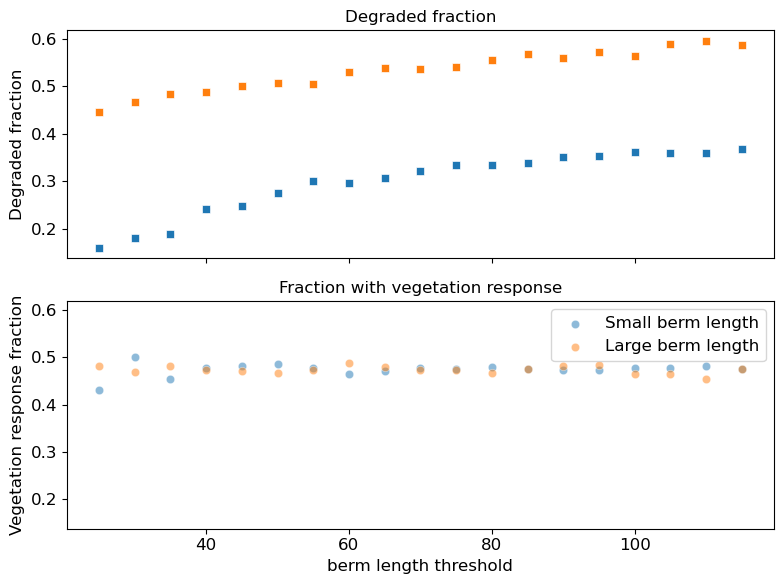

In [ ]:
# Berm length threshold sweep (meters): evaluates how low vs high length partitions differ
# in degraded and effective fractions across candidate cut points.
results_df, fig = analyze_threshold_proportions(data, 'Shape_Leng', 'berm length', np.arange(0, 120, 5))
# fig.savefig('../figures/single_variable_plots/Shape_Leng.png')

In [ ]:
[c for c in data if 'slope' in c]

['slopeD_100',
 'slopeD_200',
 'slopeD_60',
 'slopeU_100',
 'slopeU_200',
 'slopeU_60',
 'slope_100',
 'slope_200']

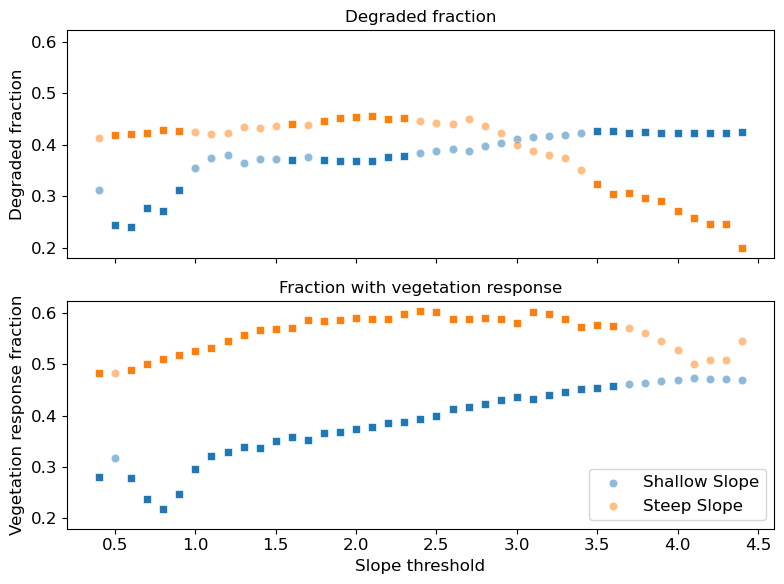

In [ ]:
# Slope threshold sweep (%): compare shallow vs steep partitions over candidate slope cut points.
results_df, fig = analyze_threshold_proportions(data, 'slope_200', 'Slope', np.arange(0, 10, 0.1), largeName = 'Steep', smallName = 'Shallow' )
# fig.savefig('../figures/single_variable_plots/Slope.png')

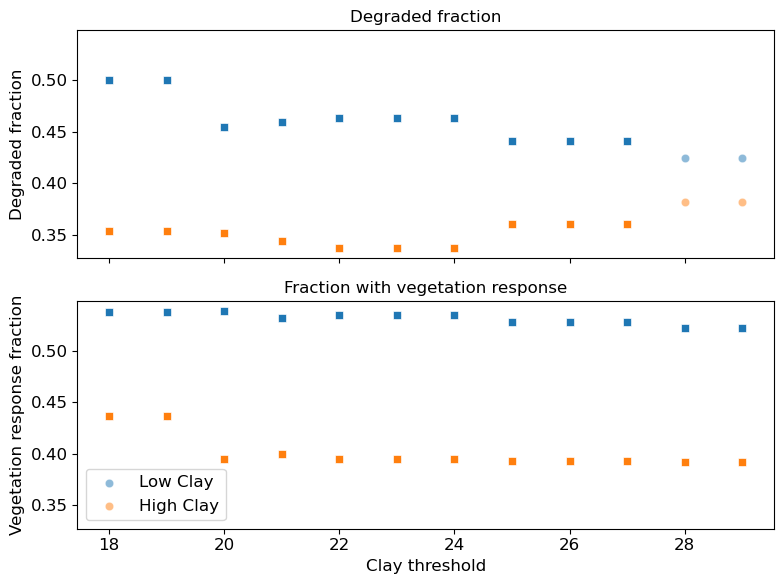

In [ ]:
# Clay threshold sweep (% claytotal_r): compare low vs high clay partitions.
results_df, fig = analyze_threshold_proportions(data, 'claytotal_r', 'Clay', np.arange(18, 30, 1), 
                                                largeName = 'High', smallName = 'Low' )
# fig.savefig('../figures/single_variable_plots/Clay.png')

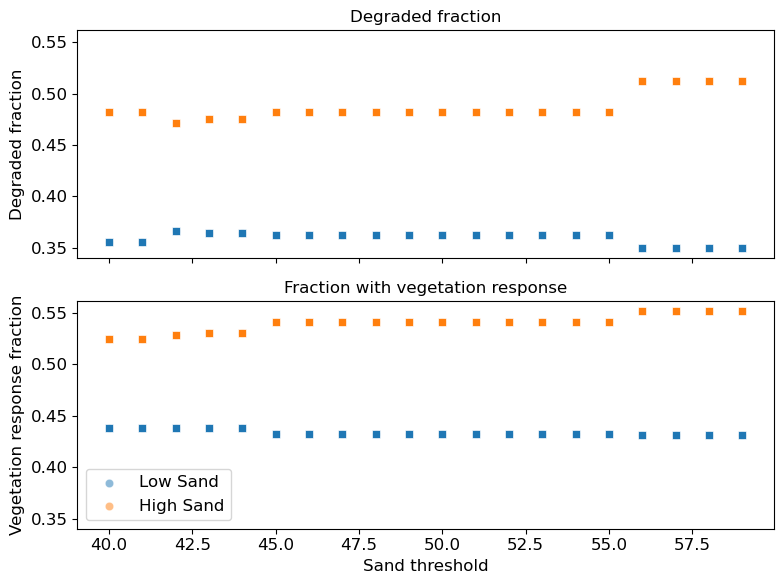

In [ ]:
# Sand threshold sweep (% sandtotal_r): compare low vs high sand partitions.
results_df, fig = analyze_threshold_proportions(data, 'sandtotal_r', 'Sand', np.arange(40, 60, 1), 
                                                largeName = 'High', smallName = 'Low' )
# fig.savefig('../figures/single_variable_plots/Sand.png')

In [ ]:
from analysis import PRETTY_LABELS, _clean_predictor_name, _format_ranking_for_si


In [ ]:
# ── Export SI predictor-ranking and scenario-summary tables as LaTeX ──────────
import os

si_dir = Path("../latex")
si_dir.mkdir(parents=True, exist_ok=True)

# ---- Table S1: Single-predictor ranking → Effective outcome ----
ranked_eff_si = _format_ranking_for_si(ranked)
ranked_eff_si.columns = [c.replace("_", " ").title() for c in ranked_eff_si.columns]

# ---- Table S2: Single-predictor ranking → Intact outcome ----
ranked_int_si = _format_ranking_for_si(ranked_intact)
ranked_int_si.columns = [c.replace("_", " ").title() for c in ranked_int_si.columns]

# ---- Table S3: Scenario summary (both targets, pretty predictor names) ----
ss_si = scenario_summary.copy()
if "top_3_predictors" in ss_si.columns:
    ss_si["top_3_predictors"] = ss_si["top_3_predictors"].apply(
        lambda s: ", ".join(_clean_predictor_name(p.strip()) for p in str(s).split(","))
    )
num_cols = ss_si.select_dtypes(include="number").columns
ss_si[num_cols] = ss_si[num_cols].round(3)
ss_si.columns = [c.replace("_", " ").title() for c in ss_si.columns]

# ---- Table S4: Length-class outcome probabilities ----
length_df_si = length_df.copy()

# ── Build a standalone SI LaTeX file ──────────────────────────────────────────
def _df_to_latex_tabular(df, caption, label):
    """Return a LaTeX table environment string for a DataFrame."""
    n_cols = len(df.columns)
    col_spec = "l" + "r" * (n_cols - 1)
    lines = [
        r"\begin{table}[H]",
        r"  \centering",
        rf"  \caption{{{caption}}}",
        rf"  \label{{{label}}}",
        r"  \small",
        rf"  \begin{{tabular}}{{{col_spec}}}",
        r"    \toprule",
        "    " + " & ".join(str(c) for c in df.columns) + r" \\",
        r"    \midrule",
    ]
    for _, row in df.iterrows():
        vals = " & ".join(str(v) if pd.notna(v) else "--" for v in row)
        lines.append(f"    {vals}" + r" \\")
    lines += [
        r"    \bottomrule",
        r"  \end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)


si_tex = r"""\documentclass[11pt, a4paper]{article}

\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage{lmodern}
\usepackage[left=2cm, right=2cm, top=2.5cm, bottom=2.5cm]{geometry}
\usepackage{booktabs}
\usepackage{caption}
\usepackage{float}
\usepackage{parskip}
\usepackage{microtype}
\usepackage{hyperref}
\hypersetup{colorlinks=true, linkcolor=black, urlcolor=blue}

\begin{document}

\begin{center}
  {\LARGE \textbf{Supplementary Information}} \\[0.4em]
  {\large Altar Valley Berms --- Paper 2} \\[0.3em]
  {\small Auto-generated from notebook analysis}
\end{center}

\vspace{1em}\hrule\vspace{1.5em}

"""

si_tex += _df_to_latex_tabular(
    ranked_eff_si,
    caption="Single-predictor ranking for Effective outcome (GLM pseudo-$R^2$, Tjur $R^2$, LRT, CV AUC).",
    label="tab:si_ranked_effective",
)
si_tex += "\n\n\\vspace{2em}\n\n"

si_tex += _df_to_latex_tabular(
    ranked_int_si,
    caption="Single-predictor ranking for Intact outcome (GLM pseudo-$R^2$, Tjur $R^2$, LRT, CV AUC).",
    label="tab:si_ranked_intact",
)
si_tex += "\n\n\\vspace{2em}\n\n"

si_tex += _df_to_latex_tabular(
    ss_si,
    caption="Random-forest scenario summary (5-fold stratified CV).",
    label="tab:si_scenario_summary",
)
si_tex += "\n\n\\vspace{2em}\n\n"

si_tex += _df_to_latex_tabular(
    length_df_si,
    caption="Conditional outcome probabilities by berm length class (threshold = 60 m). "
            "Proportions are shown for long ($>$60 m) and short ($<$60 m) berms; "
            "conditional rows (Breach $|$ failed, Flank $|$ failed) are restricted to failed berms only. "
            "$\\Delta$ is the difference in percentage points (long minus short).",
    label="tab:si_length_outcome_probs",
)
si_tex += "\n\n" + r"\end{document}" + "\n"

si_path = si_dir / "si_tables_failure_mechanisms.tex"
si_path.write_text(si_tex, encoding="utf-8")
print(f"SI tables written to {si_path}")
display(ranked_eff_si)
display(ranked_int_si)
display(ss_si)
display(length_df_si)


SI tables written to ../latex/si_tables_failure_mechanisms.tex


,Predictor,N Levels,Mcfadden R2,Tjur R2,Lrt P,Aic,Df Model,Cv Auc
1,Hillslope gradient (200 m),NaN,0.021,0.030,0.000,1010.583,1.0,0.631
2,Hillslope gradient (100 m),NaN,0.014,0.019,0.000,1017.916,1.0,0.611
5,Parent material,4.0,0.025,0.034,0.000,846.863,3.0,0.585
7,Typical soil profile,18.0,0.049,0.062,0.000,1014.165,17.0,0.577
10,"Clay content (r-horizon, %)",NaN,0.012,0.016,0.001,1020.292,1.0,0.574
14,Channel distance (1000 m),NaN,0.013,0.018,0.000,1019.096,1.0,0.574
16,Soil texture,8.0,0.027,0.037,0.000,1016.549,7.0,0.573
11,High clay,2.0,0.015,0.020,0.000,1017.263,1.0,0.570
0,Landform,3.0,0.015,0.020,0.001,1019.264,2.0,0.563
13,Channel distance (500 m),NaN,0.008,0.011,0.004,1023.847,1.0,0.562


,Predictor,N Levels,Mcfadden R2,Tjur R2,Lrt P,Aic,Df Model,Cv Auc
4,Berm length,NaN,0.038,0.051,0.000,976.161,1.0,0.661
15,Flow accumulation (30 m),NaN,0.008,0.012,0.005,1006.271,1.0,0.660
7,Typical soil profile,18.0,0.072,0.091,0.000,973.757,17.0,0.629
3,Berm length class,2.0,0.037,0.049,0.000,976.687,1.0,0.610
16,Soil texture,8.0,0.031,0.041,0.000,994.409,7.0,0.596
10,"Clay content (r-horizon, %)",NaN,0.013,0.017,0.000,1001.395,1.0,0.579
8,"Sand content (r-horizon, %)",NaN,0.012,0.017,0.000,1001.738,1.0,0.562
11,High clay,2.0,0.008,0.011,0.005,1006.238,1.0,0.552
5,Parent material,4.0,0.029,0.040,0.000,834.534,3.0,0.548
14,Channel distance (1000 m),NaN,0.005,0.006,0.032,1009.619,1.0,0.547


,Scenario,Target,Cv Auc Mean,Cv Auc Sd,Holdout Auc,Cv Bal Acc Mean,Cv F1 Mean,Top 3 Predictors,N,N Predictors
0,landscape_geomorphology_only,Intact,0.656,0.017,0.680,0.592,0.669,"Flow accumulation (30 m), Hillslope gradient (...",743,3
1,landscape_geomorphology_only,Effective,0.612,0.043,0.680,0.590,0.571,"Hillslope gradient (200 m), Landform, Flow acc...",743,3
2,soil_only,Intact,0.628,0.034,0.618,0.585,0.696,"Typical soil profile, Soil texture, Soil devel...",743,3
3,soil_only,Effective,0.579,0.030,0.621,0.577,0.542,"Typical soil profile, Soil texture, Soil devel...",743,3
4,shape_length_only,Intact,0.564,0.018,0.641,0.542,0.621,"Berm length, Berm length class",743,2
5,shape_length_only,Effective,0.558,0.036,0.497,0.533,0.499,"Berm length class, Berm length",743,2
6,all_predictors,Intact,0.728,0.011,0.772,0.656,0.707,"Flow accumulation (30 m), Berm length, Hillslo...",743,8
7,all_predictors,Effective,0.652,0.044,0.646,0.609,0.582,"Hillslope gradient (200 m), Berm length class,...",743,8
8,all_predictors + effect_percent,Intact,0.721,0.019,0.770,0.657,0.715,"Flow accumulation (30 m), Berm length, Hillslo...",743,9
9,all_predictors + Intact,Effective,0.649,0.036,0.649,0.610,0.580,"Hillslope gradient (200 m), Berm length class,...",743,9


,Long (> 50 m),Short (≤ 50 m),sig
Vegetation response,0.466518,0.486239,ns
No vegetation response,0.533482,0.513761,ns


In [ ]:
# Post-process generated LaTeX string to escape underscores and Unicode ≤, then write to disk
import re
if 'si_tex' in globals():
    si_tex = re.sub(r'(?<!\\)_', r'\\_', si_tex)
    si_tex = si_tex.replace('≤', r'\\(\\le\\)')
    if 'si_path' in globals():
        si_path.write_text(si_tex, encoding='utf-8')
        print(f'Post-processed si_tex written to {si_path}')
    else:
        print('si_path not defined; run the SI-generation cell that sets `si_path` and writes initially')
else:
    print('si_tex not defined; run the SI-generation cell first')

Post-processed si_tex written to ../latex/si_tables_failure_mechanisms.tex


## Balancing samples

This section is intentionally moved to the end so the balancing diagnostics and summary exports run after core data preparation and modeling outputs.

- Cell 1 defines a helper that balances sample counts across partitions within each group.
- Cells 2-4 write unbalanced and balanced summaries for landform, soil development, and slope partitions.

In [ ]:
import pandas as pd

# Helper: create balanced samples by matching counts across partition values
# within each grouping combination (e.g., same Landform + length class).
def balanced_sample(df, group_cols, partition_col):
    # Drop rows with missing values in relevant columns
    cols_required = group_cols + [partition_col]
    df = df.dropna(subset=cols_required)

    grouped = df.groupby(group_cols + [partition_col])
    ct = grouped.size().unstack(partition_col, fill_value=0)

    samples = []
    for idx, row in ct.iterrows():
        partition_values = row.index.tolist()
        min_n = row.min()

        # Skip unbalanced groups
        if row.nunique() == 1 or min_n == 0:
            print(f"Skipping unbalanced group: {idx} | Counts: {row.to_dict()}")
            continue

        group_filter = dict(zip(group_cols, idx if isinstance(idx, tuple) else (idx,)))
        for part_value in partition_values:
            subset = df.copy()
            for col, val in group_filter.items():
                subset = subset[subset[col] == val]
            subset = subset[subset[partition_col] == part_value]
            samples.append(subset.sample(n=min_n, random_state=42))

    return pd.concat(samples).reset_index(drop=True)


In [ ]:
# Landform summary export:
# 1) write unbalanced effective/intact distributions
# 2) write length/slope correspondence by landform
partition_col = 'Landform'

# Open file for writing
with open('landform_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\n Berm length / landform correspondence")
    
    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Berm_Length_Class']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    
    f.write("\n Slope  / landform correspondence")
    
    summary_counts = data.groupby([partition_col, 'Slope_Class']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")    
    
 

In [ ]:
# Soil-development summary export:
# 1) report unbalanced effective/intact distributions
# 2) create balanced subsets with one and two grouping schemes
# 3) write balanced counts/proportions for comparison
partition_col = 'Soil_Development'

# Open file for writing
with open('soil_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Slope_Class']   
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Slope_Class', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 

In [ ]:
# Slope-class summary export:
# 1) report unbalanced effective/intact distributions
# 2) rebalance across Landform and Landform+Length groupings
# 3) compare balanced counts/proportions against unbalanced baseline
# Choose grouping and partition variables
partition_col = 'Slope_Class'

# Open file for writing
with open('slope_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Landform']    
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Landform', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 